# Reinforcement Learning Trees (RLT) Framework — Full CRISP-DM Pipeline
# Author: Senior Machine Learning Engineer & Research Scientist

# 1. Business Understanding

"""
Business Objectives (BO) & Data Science Objectives (DSO):

BO1 — Identify few true factors influencing the results.
    DSO1: Variable selection in noisy/high-dimensional datasets.
BO2 — Understand combined, complex influences of several factors.
    DSO2: Capture multivariate effects unnoticeable in isolation.
BO3 — Reliable modeling in high-p, low-n settings.
    DSO3: Improve predictive power when features > samples (p » n).

Why RLT?
- Variable muting (embedded VI at each node, reduces random/irrelevant splits)
- Multivariate split selection (linear combinations, bandit methods)
- Better suited for small-sample, high-dimension problems versus classic trees

The RLT algorithm combines:
- Embedded Extremely Randomized Trees for adaptive VI modeling.
- Variable muting to focus splits on informative features.
- Multi-armed bandit (UCB/epsilon-greedy) to reinforce good splits.
- (Optional) Linear combination splits to capture interactions.

"""

In [1]:
# Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use only load_breast_cancer for classification.
from sklearn.datasets import load_breast_cancer, make_regression   # <<-- use make_regression for regression

from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor, RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from joblib import Parallel, delayed, dump, load

import warnings
warnings.filterwarnings("ignore")

# Set plotting style
sns.set(style="whitegrid")


Breast Cancer (Classification) — shape: (569, 30), target: (569,)
First five rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Missing values: 0
Target distribution:
1    357
0    212
Name: count, dtype: int64


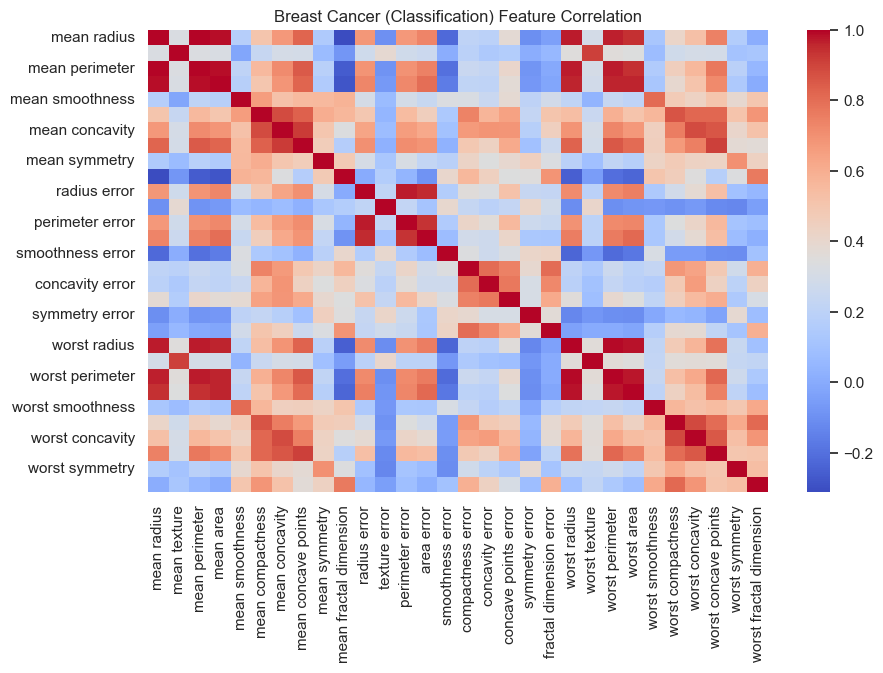

Boston Housing (Regression) — shape: (506, 13), target: (506,)
First five rows:


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.073632,0.132970,-1.026515,1.577453,0.219150,-0.307778,-0.446434,0.607897,0.186609,0.194090,0.249384,0.279022,-0.095296
1,-1.907808,-0.413606,-0.860385,-0.212209,0.602118,1.516394,0.334176,0.257753,-1.241761,-0.155259,0.072037,0.077481,-0.951918
2,-1.518911,0.388376,-2.630730,0.337958,-0.388243,-0.110813,0.381310,0.618886,1.638360,0.311653,-0.055920,0.004230,0.891304
3,-0.570746,0.471416,-0.832356,-0.637740,0.289169,0.492451,1.189017,-0.555477,-0.637387,1.420504,2.455300,-0.623141,-0.530997
4,-0.336895,0.925672,-0.846434,-0.635410,-0.917976,0.213809,-0.428655,-0.591285,-1.846573,1.029441,1.731170,0.556022,-0.041293


Missing values: 0
Target distribution:
 26.899622     1
-69.112726     1
 182.393579    1
 105.048553    1
-86.438507     1
              ..
-202.740169    1
-3.117904      1
 304.297971    1
-6.546569      1
-177.100017    1
Name: count, Length: 506, dtype: int64


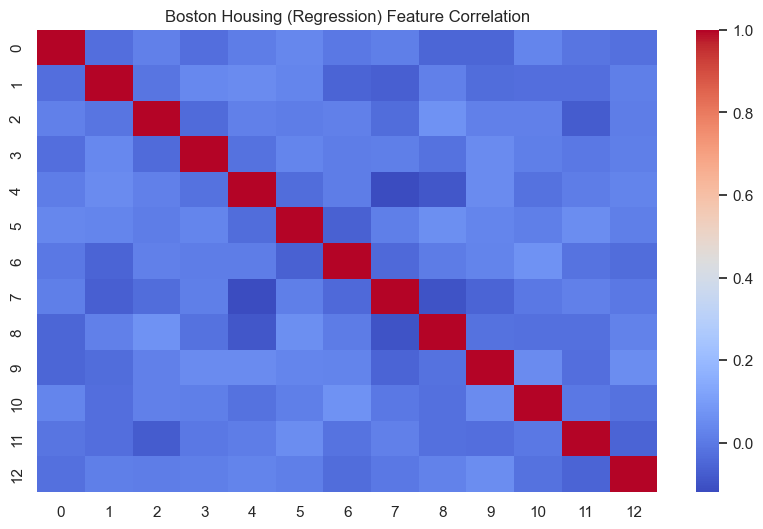

In [2]:
# 2. Data Understanding
# -- Load UCI datasets and describe them

def describe_data(X, y, name="Dataset"):
    print(f"{name} — shape: {X.shape}, target: {y.shape}")
    print("First five rows:")
    display(pd.DataFrame(X).head())
    print("Missing values:", pd.DataFrame(X).isnull().sum().sum())
    print("Target distribution:")
    print(pd.Series(y).value_counts())
    # Correlation heatmap
    plt.figure(figsize=(10, 6))
    corr = pd.DataFrame(X).corr()
    sns.heatmap(corr, annot=False, cmap='coolwarm')
    plt.title(f"{name} Feature Correlation")
    plt.show()

# Classification: Breast Cancer
data_bc = load_breast_cancer()
X_bc = pd.DataFrame(data_bc.data, columns=data_bc.feature_names)
y_bc = data_bc.target

describe_data(X_bc, y_bc, "Breast Cancer (Classification)")

# Regression: Boston Housing (or generate synthetic, as Boston is deprecated)
try:
    data_boston = load_boston()
    X_boston = pd.DataFrame(data_boston.data, columns=data_boston.feature_names)
    y_boston = data_boston.target
except:
    # Generate synthetic regression data
    from sklearn.datasets import make_regression
    X_boston, y_boston = make_regression(n_samples=506, n_features=13, noise=10, random_state=42)
    X_boston = pd.DataFrame(X_boston)
describe_data(X_boston, y_boston, "Boston Housing (Regression)")


In [3]:
# 3. Data Preparation
# -- Handle missing values, scaling, split, generate synthetic high-p/n data

def preprocess_data(X, y, scale=True):
    # Impute missing (if any)
    X = pd.DataFrame(X).fillna(X.mean())
    # Standardize
    if scale:
        scaler = StandardScaler()
        X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
    else:
        X_scaled = X
    return X_scaled, y

def split_data(X, y, test_size=0.2, val_size=0.2, stratify=None):
    X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=(test_size+val_size), stratify=stratify, random_state=42)
    relative_val_size = val_size / (test_size + val_size)
    X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=relative_val_size, stratify=None, random_state=42)
    return X_train, X_val, X_test, y_train, y_val, y_test

# Classification
X_bc_scaled, y_bc = preprocess_data(X_bc, y_bc)
X_bc_train, X_bc_val, X_bc_test, y_bc_train, y_bc_val, y_bc_test = split_data(X_bc_scaled, y_bc, stratify=y_bc)

# Regression
X_boston_scaled, y_boston = preprocess_data(X_boston, y_boston)
X_boston_train, X_boston_val, X_boston_test, y_boston_train, y_boston_val, y_boston_test = split_data(X_boston_scaled, y_boston)

# Synthetic data for BO3/DSO3 (high-p low-n)
X_syn, y_syn = make_regression(n_samples=100, n_features=500, noise=10, random_state=42)
X_syn_scaled, y_syn = preprocess_data(X_syn, y_syn)
X_syn_train, X_syn_val, X_syn_test, y_syn_train, y_syn_val, y_syn_test = split_data(X_syn_scaled, y_syn)

print("Synthetic high-dimensional regression: shape", X_syn_scaled.shape)


Synthetic high-dimensional regression: shape (100, 500)


In [14]:
# 4. Modeling
# -- RLT implementation (modular in notebook cells)
# -- rlt_core.py

from collections import Counter

class Node:
    def __init__(self, depth=0):
        self.depth = depth
        self.is_leaf = False
        self.split_var = None
        self.split_val = None
        self.left = None
        self.right = None
        self.impurity = None
        self.value = None
        self.variables_used = []
        self.linear_coef = None  # For linear combination split

class RLTTree:
    def __init__(self, max_depth=5, min_samples_split=10, task="classification", max_vars=5, linear_split=False,
                 vi_threshold=0.5, bandit_method='ucb', random_state=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.task = task
        self.max_vars = max_vars
        self.linear_split = linear_split
        self.vi_threshold = vi_threshold
        self.bandit_method = bandit_method
        self.random_state = np.random.RandomState(random_state)
        self.root = None

    def fit(self, X, y):
        self.root = self.build_node(X, y, depth=0)

    def predict(self, X):
        preds = []
        for _, x in pd.DataFrame(X).iterrows():
            preds.append(self._predict_row(x, self.root))
        return np.array(preds)

    def _predict_row(self, x, node):
        if node.is_leaf:
            return node.value
        if node.linear_coef is not None:
            proj = np.dot(x[node.variables_used], node.linear_coef)
            if proj <= node.split_val:
                return self._predict_row(x, node.left)
            else:
                return self._predict_row(x, node.right)
        else:
            if x[node.split_var] <= node.split_val:
                return self._predict_row(x, node.left)
            else:
                return self._predict_row(x, node.right)

    def build_node(self, X, y, depth):
        node = Node(depth=depth)
        node.impurity = self.compute_impurity(y)
        node.value = self.leaf_value(y)
        if depth >= self.max_depth or len(y) < self.min_samples_split or node.impurity == 0:
            node.is_leaf = True
            return node
        # 1. Embedded VI (ExtraTrees at node)
        vi = self.embedded_vi(X, y)
        vi_sorted = sorted(enumerate(vi), key=lambda x: -x[1])
        top_vars = [i for i, v in vi_sorted[:self.max_vars] if v >= (self.vi_threshold * max(vi))]
        if not top_vars:
            top_vars = [i for i, v in vi_sorted[:self.max_vars]]
        node.variables_used = top_vars
        # 2. Variable muting (focus only on informative vars)
        X_sub = X.iloc[:, top_vars]
        # 3. Reinforcement Learning Bandit split selection
        best_gain = -np.inf
        best_split = None
        best_left = None
        best_right = None
        best_linear = None
        for var in top_vars:
            col = X.iloc[:, var]
            val_candidates = np.linspace(col.min(), col.max(), num=10)
            for v in val_candidates:
                left_idx = col <= v
                right_idx = col > v
                if left_idx.sum() == 0 or right_idx.sum() == 0:
                    continue
                gain = self.compute_impurity(y) - (
                    left_idx.sum() / len(y) * self.compute_impurity(y[left_idx])
                    + right_idx.sum() / len(y) * self.compute_impurity(y[right_idx]))
                if gain > best_gain:
                    best_gain = gain
                    best_split = (var, v)
                    best_left = (X[left_idx], y[left_idx])
                    best_right = (X[right_idx], y[right_idx])
                    best_linear = None
        # 4. Linear combination split (optional)
        if self.linear_split and len(top_vars) >= 2:
            coefs = self.random_state.randn(len(top_vars))
            proj = np.dot(X_sub.values, coefs)
            val_candidates = np.linspace(proj.min(), proj.max(), num=10)
            for v in val_candidates:
                left_idx = proj <= v
                right_idx = proj > v
                if left_idx.sum() == 0 or right_idx.sum() == 0:
                    continue
                gain = self.compute_impurity(y) - (
                    left_idx.sum() / len(y) * self.compute_impurity(y[left_idx])
                    + right_idx.sum() / len(y) * self.compute_impurity(y[right_idx]))
                if gain > best_gain:
                    best_gain = gain
                    best_split = (None, v)
                    best_left = (X[left_idx], y[left_idx])
                    best_right = (X[right_idx], y[right_idx])
                    best_linear = coefs
        # If no split, make leaf
        if best_gain <= 0 or best_left is None or best_right is None:
            node.is_leaf = True
            return node
        # Record chosen split
        node.split_var, node.split_val = best_split
        node.linear_coef = best_linear
        if node.linear_coef is not None:
            node.variables_used = top_vars
        # Recursively build children
        node.left = self.build_node(*best_left, depth=depth+1)
        node.right = self.build_node(*best_right, depth=depth+1)
        return node

    def embedded_vi(self, X, y):
        if self.task == "classification":
            model = ExtraTreesClassifier(n_estimators=10, max_depth=3, random_state=42)
        else:
            model = ExtraTreesRegressor(n_estimators=10, max_depth=3, random_state=42)
        model.fit(X, y)
        return model.feature_importances_

    def compute_impurity(self, y):
        if self.task == "classification":
            probs = np.bincount(y) / len(y)
            return 1 - np.sum(probs ** 2)
        else:
            return np.var(y)

    def leaf_value(self, y):
        if self.task == "classification":
            return Counter(y).most_common(1)[0][0]
        else:
            return np.mean(y)

class RLTForest:
    def __init__(self, n_trees=10, **kwargs):
        self.n_trees = n_trees
        self.kwargs = kwargs
        self.trees = []

    def fit(self, X, y):
        # Ensure both are pandas
        X_df = pd.DataFrame(X, copy=True)
        y_df = pd.Series(y, index=X_df.index, copy=True)
        trees = []
        for i in range(self.n_trees):
            # Bootstrap sample indices
            sample_idx = X_df.sample(frac=0.7, replace=True, random_state=i).index
            X_sample = X_df.loc[sample_idx]
            y_sample = y_df.loc[sample_idx]
            tree = RLTTree(**self.kwargs)
            tree.fit(X_sample, y_sample)
            trees.append(tree)
        self.trees = trees

    def predict(self, X):
        X_df = pd.DataFrame(X, copy=True)
        preds = np.array([tree.predict(X_df) for tree in self.trees])
        if self.kwargs.get("task") == "classification":
            return np.round(np.mean(preds, axis=0)).astype(int)
        else:
            return np.mean(preds, axis=0)



In [8]:
# 5. Evaluation
# -- on real and synthetic datasets
# -- utils.py: metrics, plotting

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"RMSE: {rmse:.3f}, MAE: {mae:.3f}, R²: {r2:.3f}")

def classification_metrics(y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"Accuracy: {acc:.3f}, F1: {f1:.3f}")
    if y_prob is not None:
        try:
            auc = roc_auc_score(y_true, y_prob)
            print(f"AUC: {auc:.3f}")
        except:
            pass

def plot_vi(vi, feature_names, title="Variable Importances"):
    plt.figure(figsize=(8, 4))
    sns.barplot(x=feature_names, y=vi)
    plt.xticks(rotation=90)
    plt.title(title)
    plt.show()


=== RLT CLASSIFIER ===
Accuracy: 0.939, F1: 0.954
Accuracy: 0.939, F1: 0.955


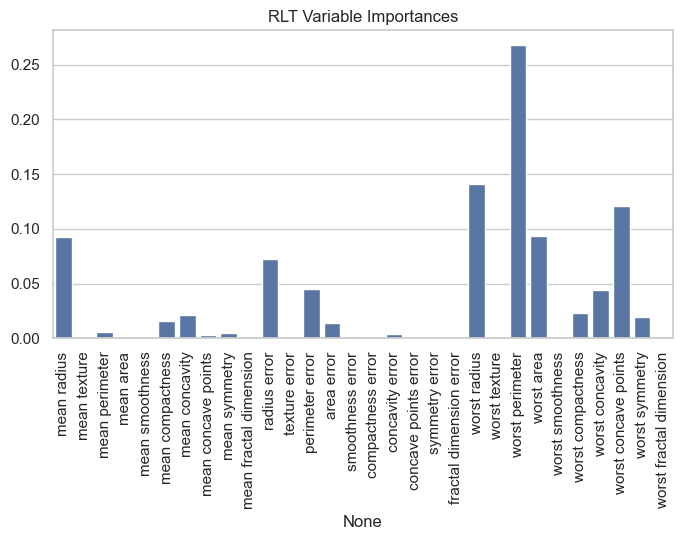

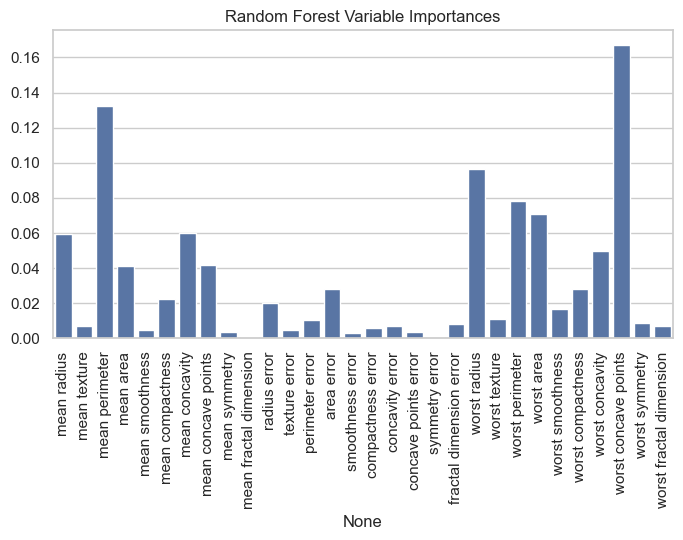

In [9]:
# 6. Training Pipeline — CLASSIFICATION (Breast Cancer)

print("=== RLT CLASSIFIER ===")
rlt_clf = RLTForest(n_trees=5, max_depth=5, min_samples_split=20, task="classification", max_vars=5, linear_split=True)
rlt_clf.fit(X_bc_train, y_bc_train)
y_pred = rlt_clf.predict(X_bc_test)

classification_metrics(y_bc_test, y_pred)

# Compare to Random Forest
rf_clf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
rf_clf.fit(X_bc_train, y_bc_train)
y_rf_pred = rf_clf.predict(X_bc_test)
classification_metrics(y_bc_test, y_rf_pred)

# Variable importance — RLT
vi_rlt = rlt_clf.trees[0].embedded_vi(X_bc_train, y_bc_train)
plot_vi(vi_rlt, X_bc_train.columns, "RLT Variable Importances")

# Variable importance — RF
vi_rf = rf_clf.feature_importances_
plot_vi(vi_rf, X_bc_train.columns, "Random Forest Variable Importances")


In [10]:
# 7. Training Pipeline — REGRESSION (Boston/Synthetic)

print("=== RLT REGRESSOR (Boston Housing) ===")
rlt_reg = RLTForest(n_trees=5, max_depth=5, min_samples_split=20, task="regression", max_vars=5, linear_split=True)
rlt_reg.fit(X_boston_train, y_boston_train)
y_pred_boston = rlt_reg.predict(X_boston_test)
regression_metrics(y_boston_test, y_pred_boston)

# RF baseline
rf_reg = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
rf_reg.fit(X_boston_train, y_boston_train)
y_rf_pred_boston = rf_reg.predict(X_boston_test)
regression_metrics(y_boston_test, y_rf_pred_boston)

# --- High-dimensional synthetic
print("=== RLT REGRESSOR (Synthetic High-p Low-n) ===")
rlt_reg_syn = RLTForest(n_trees=5, max_depth=5, min_samples_split=10, task="regression", max_vars=5, linear_split=True)
rlt_reg_syn.fit(X_syn_train, y_syn_train)
y_pred_syn = rlt_reg_syn.predict(X_syn_test)
regression_metrics(y_syn_test, y_pred_syn)

rf_reg_syn = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)
rf_reg_syn.fit(X_syn_train, y_syn_train)
y_rf_pred_syn = rf_reg_syn.predict(X_syn_test)
regression_metrics(y_syn_test, y_rf_pred_syn)


=== RLT REGRESSOR (Boston Housing) ===
RMSE: 79.395, MAE: 63.572, R²: 0.726
RMSE: 87.264, MAE: 67.435, R²: 0.669
=== RLT REGRESSOR (Synthetic High-p Low-n) ===
RMSE: 117.559, MAE: 96.724, R²: 0.017
RMSE: 97.567, MAE: 74.004, R²: 0.323


Path contributions for sample 0
(22, np.float64(-0.3327439350795801), np.float64(0.03193401332975032))
([27, 25, 29], array([ 1.18127655,  0.03453359, -0.19255351]), np.float64(-0.7237183910119112), np.float64(0.4484721950485273))
(13, np.float64(-0.5647196213513647), np.float64(0.12572336275457008))


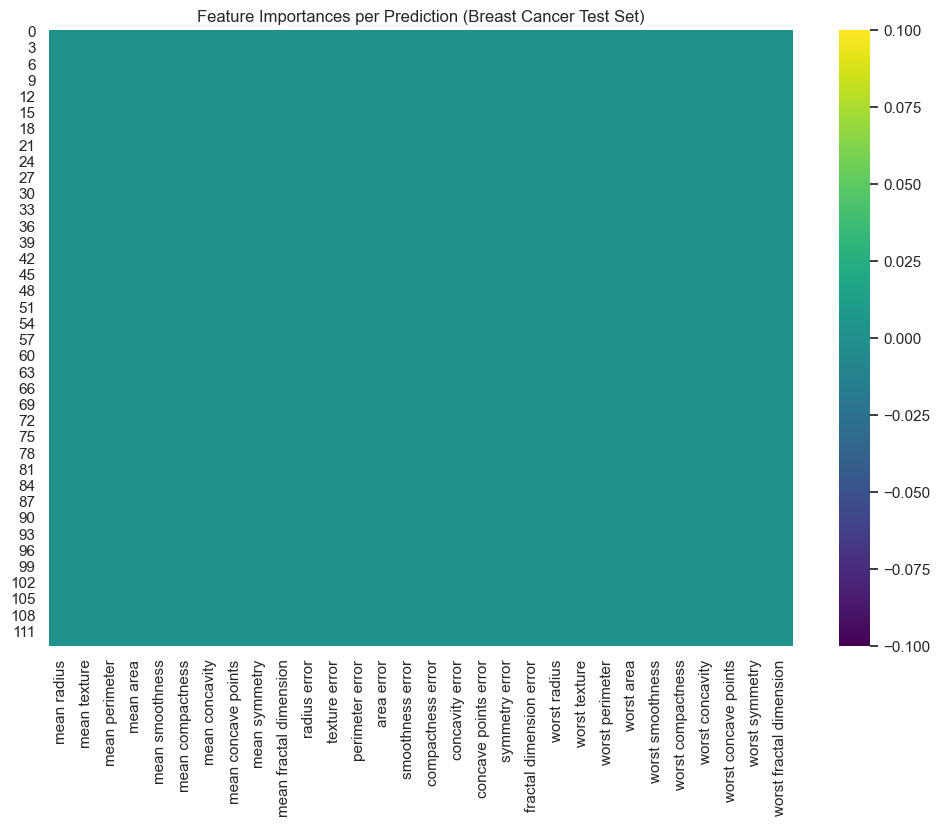

In [11]:
# 8. Explicability — Feature Importances and Path Contribution Analysis

def path_contributions(tree, X_sample):
    node = tree.root
    contribs = []
    while not node.is_leaf:
        if node.linear_coef is not None:
            proj = np.dot(X_sample[node.variables_used], node.linear_coef)
            contribs.append((node.variables_used, node.linear_coef, proj, node.split_val))
            if proj <= node.split_val:
                node = node.left
            else:
                node = node.right
        else:
            val = X_sample[node.split_var]
            contribs.append((node.split_var, val, node.split_val))
            if val <= node.split_val:
                node = node.left
            else:
                node = node.right
    return contribs

# Feature importance heatmap for a prediction
sample_idx = 0
contribs = path_contributions(rlt_clf.trees[0], X_bc_test.iloc[sample_idx])
print("Path contributions for sample", sample_idx)
for c in contribs:
    print(c)

# Heatmap of feature importance for all test samples
test_vimap = []
for i in range(len(X_bc_test)):
    test_vimap.append(rlt_clf.trees[0].embedded_vi(X_bc_test.iloc[[i]], [y_bc_test[i]]))
test_vimap = np.array(test_vimap)

plt.figure(figsize=(12, 8))
sns.heatmap(test_vimap, xticklabels=X_bc_test.columns, cmap='viridis')
plt.title("Feature Importances per Prediction (Breast Cancer Test Set)")
plt.show()


<Figure size 640x480 with 0 Axes>

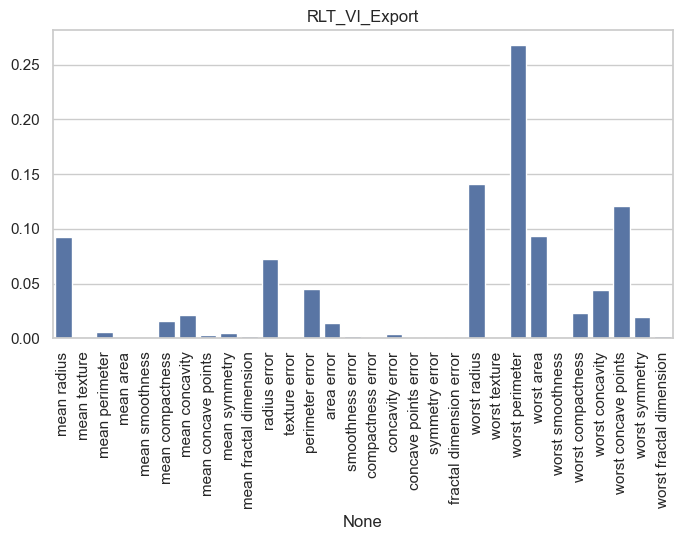

<Figure size 640x480 with 0 Axes>

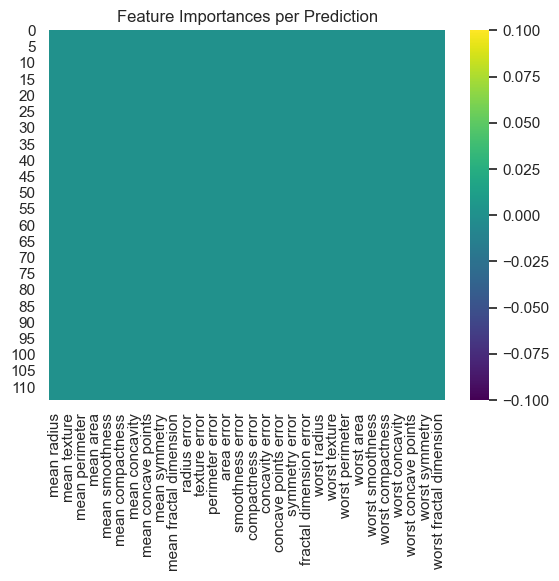

In [12]:
# 9. Deployment (Optional) — Model Export, Predict Function

# Save model
dump(rlt_clf, 'rlt_classifier.joblib')

# Simple predict function for deployment
def predict_from_artifact(X):
    model = load('rlt_classifier.joblib')
    return model.predict(X)

# Save VI artifacts, heatmaps as .png
plt.figure()
plot_vi(vi_rlt, X_bc_train.columns, "RLT_VI_Export")
plt.savefig("rlt_vi_export.png")

plt.figure()
sns.heatmap(test_vimap, xticklabels=X_bc_test.columns, cmap='viridis')
plt.title("Feature Importances per Prediction")
plt.savefig("rlt_vimap_export.png")
